In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

=== داده‌ها با موفقیت لود شدند ===
                           mean        std       min       max
P80_Micron            76.223450   2.044453    72.010    82.370
FeO_Percent            1.617735   0.148566     1.288     2.025
BurnerZoneTemp_C    1245.659500  10.406884  1216.600  1270.800
O2_Percent             2.717050   0.239897     2.180     3.230
SpecificPower_kWht    19.208450   1.051524    17.580    21.900
ReturnLoad_th        305.282000  24.171061   241.700   358.600
FeedHardness_Index     0.133650   1.030126    -2.900     2.440
FeedRate_th          420.047000   7.887869   399.300   440.600

=== سیگنال‌های CUSUM ===
First positive CUSUM signal: 10
First negative CUSUM signal: None

=== تحلیل تأخیر زمانی (Lag Analysis) ===
Lag with max |correlation|: 1 Hours (Corr: -0.385)


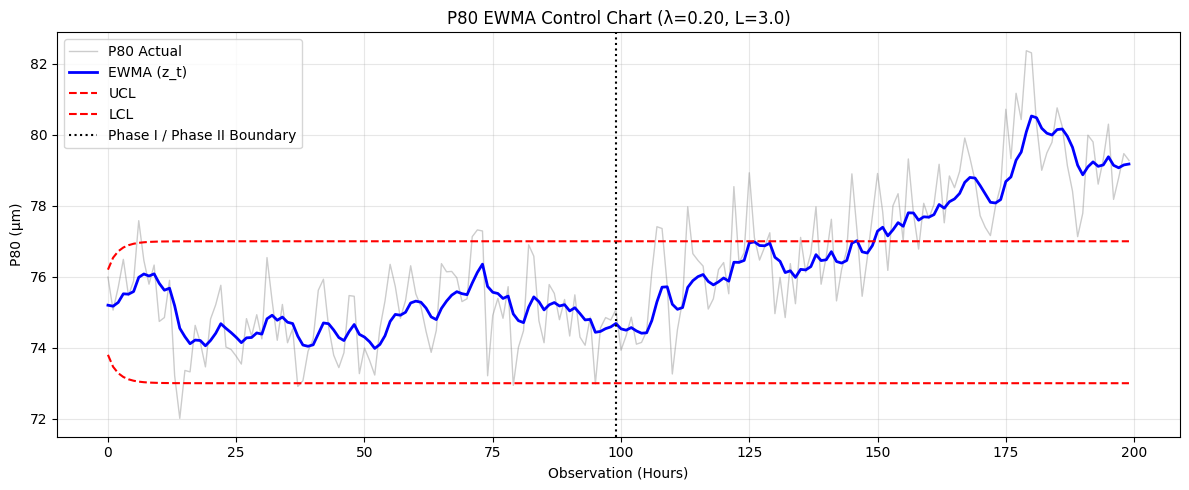

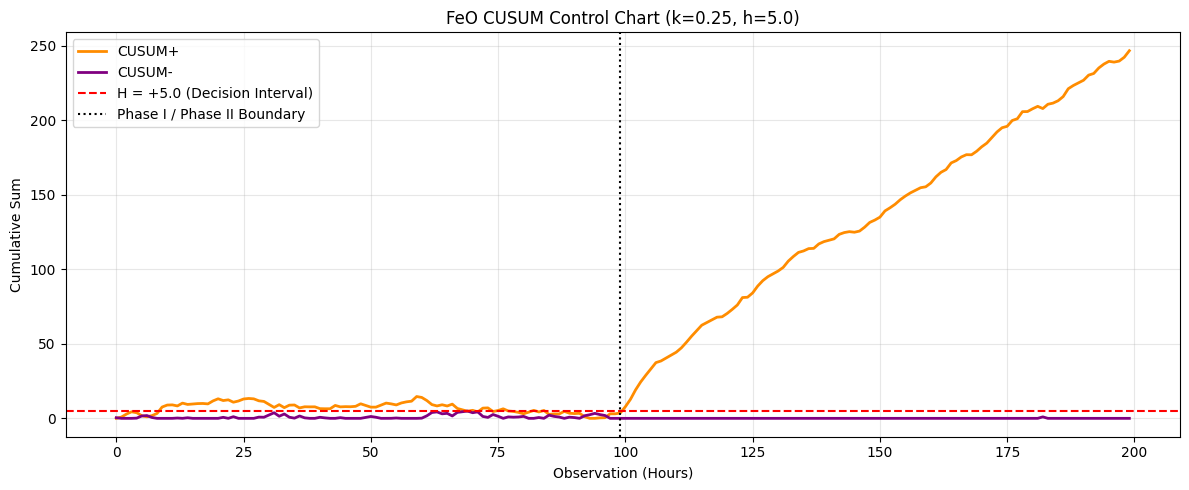

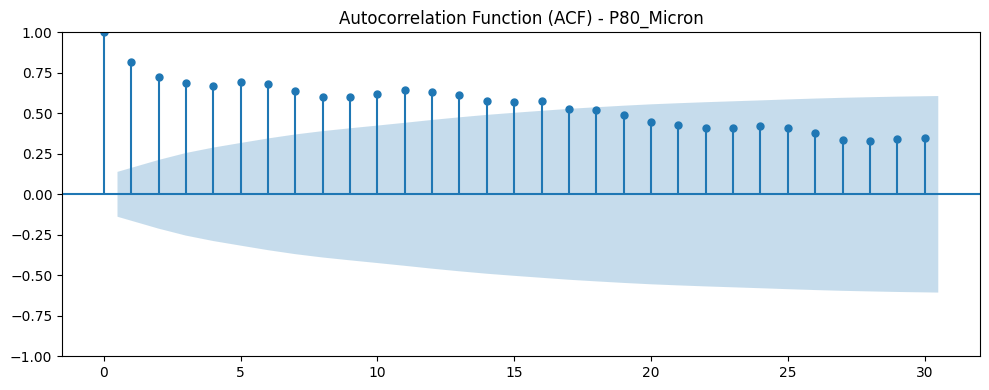

In [2]:
# ۱. بارگذاری داده
FILE_PATH = "/home/qc/Process_Data_Chapter7_EWMA_CUSUM.xlsx"  # مسیر فایل اکسل خودت را بگذار

df = pd.read_excel(FILE_PATH, sheet_name="Data")

required_columns = [
    "P80_Micron", "FeO_Percent", "BurnerZoneTemp_C", "O2_Percent",
    "SpecificPower_kWht", "ReturnLoad_th", "FeedHardness_Index", "FeedRate_th"
]

missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("=== داده‌ها با موفقیت لود شدند ===")
print(df[required_columns].describe().T[["mean", "std", "min", "max"]])

# ۲. توابع هسته SPC
def calculate_ewma(data, lam=0.20, mu0=75.0, sigma0=2.0, L=3.0):
    data = np.asarray(data, dtype=float)
    n = len(data)
    z = np.zeros(n)
    ucl = np.zeros(n)
    lcl = np.zeros(n)

    z_prev = mu0
    for t in range(n):
        z[t] = lam * data[t] + (1 - lam) * z_prev
        z_prev = z[t]

        time_index = t + 1
        variance_factor = (lam / (2 - lam)) * (1 - (1 - lam) ** (2 * time_index))
        ewma_sigma = sigma0 * np.sqrt(variance_factor)

        ucl[t] = mu0 + L * ewma_sigma
        lcl[t] = mu0 - L * ewma_sigma

    return z, ucl, lcl

def calculate_cusum(data, mu0=1.50, sigma0=0.08, k=0.25, h=5.0):
    data = np.asarray(data, dtype=float)
    y = (data - mu0) / sigma0
    n = len(data)

    c_plus = np.zeros(n)
    c_minus = np.zeros(n)

    # مقداردهی اولیه نقطه ۰
    c_plus[0] = max(0.0, y[0] - k)
    c_minus[0] = max(0.0, -y[0] - k)

    for t in range(1, n):
        c_plus[t] = max(0.0, c_plus[t - 1] + y[t] - k)
        c_minus[t] = max(0.0, c_minus[t - 1] - y[t] - k)

    alarm_plus = c_plus >= h
    alarm_minus = c_minus >= h

    return c_plus, c_minus, alarm_plus, alarm_minus

# ۳. اجرای محاسبات
z_p80, ucl_p80, lcl_p80 = calculate_ewma(df["P80_Micron"].values, lam=0.20, mu0=75.0, sigma0=2.0, L=3.0)
cusum_plus, cusum_minus, alarm_plus, alarm_minus = calculate_cusum(df["FeO_Percent"].values, mu0=1.50, sigma0=0.08, k=0.25, h=5.0)

# ۴. بررسی اولین سیگنال‌ها
plus_indices = np.where(alarm_plus)[0]
minus_indices = np.where(alarm_minus)[0]

print("\n=== سیگنال‌های CUSUM ===")
print("First positive CUSUM signal:", plus_indices[0] + 1 if len(plus_indices) > 0 else "None")
print("First negative CUSUM signal:", minus_indices[0] + 1 if len(minus_indices) > 0 else "None")

# ۵. تحلیل Lag دمای مشعل و FeO
max_lag = 14
lag_results = []
for lag in range(max_lag + 1):
    shifted_temp = df["BurnerZoneTemp_C"].shift(lag)
    correlation = shifted_temp.corr(df["FeO_Percent"])
    lag_results.append({"Lag_Hours": lag, "Correlation": correlation})

lag_df = pd.DataFrame(lag_results)
valid_lags = lag_df.dropna(subset=["Correlation"])
best_row = valid_lags.loc[valid_lags["Correlation"].abs().idxmax()]

print("\n=== تحلیل تأخیر زمانی (Lag Analysis) ===")
print(f"Lag with max |correlation|: {int(best_row['Lag_Hours'])} Hours (Corr: {best_row['Correlation']:.3f})")

# ۶. رسم نمودار EWMA
plt.figure(figsize=(12, 5))
plt.plot(df["P80_Micron"], linewidth=1, alpha=0.4, label="P80 Actual", color="gray")
plt.plot(z_p80, linewidth=2, label="EWMA (z_t)", color="blue")
plt.plot(ucl_p80, linestyle="--", color="red", label="UCL")
plt.plot(lcl_p80, linestyle="--", color="red", label="LCL")
plt.axvline(99, linestyle=":", color="black", label="Phase I / Phase II Boundary")
plt.title("P80 EWMA Control Chart (λ=0.20, L=3.0)")
plt.xlabel("Observation (Hours)")
plt.ylabel("P80 (µm)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# ۷. رسم نمودار CUSUM
plt.figure(figsize=(12, 5))
plt.plot(cusum_plus, linewidth=2, label="CUSUM+", color="darkorange")
plt.plot(cusum_minus, linewidth=2, label="CUSUM-", color="purple")
plt.axhline(5.0, linestyle="--", color="red", label="H = +5.0 (Decision Interval)")
plt.axvline(99, linestyle=":", color="black", label="Phase I / Phase II Boundary")
plt.title("FeO CUSUM Control Chart (k=0.25, h=5.0)")
plt.xlabel("Observation (Hours)")
plt.ylabel("Cumulative Sum")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# ۸. نمودار خودهمبستگی ACF برای P80
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df["P80_Micron"].dropna(), lags=30, ax=ax)
ax.set_title("Autocorrelation Function (ACF) - P80_Micron")
plt.tight_layout()
plt.show()
